# 11 · Gradient Boosting — XGBoost & LightGBM

**Difficulty:** Intermediate-Advanced | **Time:** ~3 hours

Gradient Boosting wins most Kaggle competitions. It's one of the most powerful ML algorithms.

## Table of Contents
1. Boosting vs Bagging Concept
2. Gradient Boosting Intuition
3. sklearn GradientBoostingClassifier
4. XGBoost — The Competition Winner
5. LightGBM — Faster for Large Data
6. Early Stopping & Learning Curves
7. Real-World Project: Employee Attrition

## 1. Bagging vs Boosting

```
BAGGING (Random Forest):              BOOSTING (XGBoost):
  Each tree independent                Each tree fixes errors of previous
  Train in PARALLEL                    Train SEQUENTIALLY
  Reduces VARIANCE                     Reduces BIAS
  
  Tree1 ──────┐                       Tree1 → wrong predictions
  Tree2 ──────┤ → Vote → Result       Tree2 → focuses on those wrong ones
  Tree3 ──────┘                       Tree3 → focuses on still-wrong ones
                                      Sum → Result
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Employee attrition dataset
np.random.seed(42)
n = 2000

emp = pd.DataFrame({
    'age'              : np.random.randint(22, 60, n),
    'monthly_income'   : np.random.randint(20000, 150000, n),
    'years_at_company' : np.random.randint(0, 30, n),
    'overtime'         : np.random.choice([0, 1], n, p=[0.6, 0.4]),
    'job_satisfaction' : np.random.randint(1, 5, n),
    'work_life_balance': np.random.randint(1, 5, n),
    'num_companies'    : np.random.randint(0, 8, n),
    'distance_from_home': np.random.randint(1, 30, n),
    'training_last_year': np.random.randint(0, 6, n),
    'performance_rating': np.random.randint(1, 5, n),
})

attrition_prob = (0.5
    - emp['job_satisfaction'] * 0.08
    - emp['work_life_balance'] * 0.06
    + emp['overtime'] * 0.15
    - emp['years_at_company'] * 0.01
    + emp['num_companies'] * 0.04
    + emp['distance_from_home'] * 0.005
    + np.random.normal(0, 0.2, n))
attrition_prob = 1 / (1 + np.exp(-attrition_prob * 3))
emp['attrition'] = (np.random.random(n) < attrition_prob).astype(int)

print(f"Dataset: {emp.shape} | Attrition rate: {emp['attrition'].mean():.1%}")
print(emp.head())

Dataset: (2000, 11) | Attrition rate: 67.5%
   age  monthly_income  years_at_company  overtime  job_satisfaction  \
0   50           44226                 3         0                 3   
1   36           26721                13         0                 2   
2   29           76154                 9         1                 3   
3   42           40609                 2         0                 4   
4   40           72130                24         1                 3   

   work_life_balance  num_companies  distance_from_home  training_last_year  \
0                  3              4                  24                   4   
1                  2              1                  25                   5   
2                  3              5                  22                   1   
3                  1              1                  16                   4   
4                  4              3                   7                   5   

   performance_rating  attrition  
0            

In [2]:
X = emp.drop('attrition', axis=1)
y = emp['attrition']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Compare: Logistic Reg vs RF vs GBM
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
}

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'F1 (churn)':>12}")
print("-" * 60)
for name, model in models.items():
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:,1]
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    from sklearn.metrics import f1_score
    f1 = f1_score(y_te, y_pred)
    print(f"{name:<25} {acc:>10.2%} {auc:>10.3f} {f1:>12.3f}")

Model                       Accuracy    AUC-ROC   F1 (churn)
------------------------------------------------------------
Logistic Regression           61.25%      0.666        0.665


Random Forest                 63.00%      0.588        0.733


Gradient Boosting             65.25%      0.578        0.777


## 2. XGBoost — eXtreme Gradient Boosting

In [3]:
try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available:", xgb.__version__)
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed. Using GradientBoostingClassifier as equivalent.")
    print("Install: pip install xgboost")

if HAS_XGB:
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
    xgb_model.fit(X_tr_s, y_tr,
                  eval_set=[(X_te_s, y_te)],
                  verbose=False)
    xgb_pred = xgb_model.predict(X_te_s)
    xgb_prob = xgb_model.predict_proba(X_te_s)[:,1]
    print(f"XGBoost Accuracy: {accuracy_score(y_te, xgb_pred):.2%}")
    print(f"XGBoost AUC-ROC : {roc_auc_score(y_te, xgb_prob):.3f}")
else:
    # Use sklearn GBM as XGBoost equivalent
    xgb_model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                            max_depth=4, subsample=0.8, random_state=42)
    xgb_model.fit(X_tr_s, y_tr)
    xgb_pred = xgb_model.predict(X_te_s)
    xgb_prob = xgb_model.predict_proba(X_te_s)[:,1]
    print(f"GBM Accuracy: {accuracy_score(y_te, xgb_pred):.2%}")
    print(f"GBM AUC-ROC : {roc_auc_score(y_te, xgb_prob):.3f}")

XGBoost available: 3.3.0


XGBoost Accuracy: 63.50%
XGBoost AUC-ROC : 0.580


## 3. Feature Importance & SHAP-style Analysis

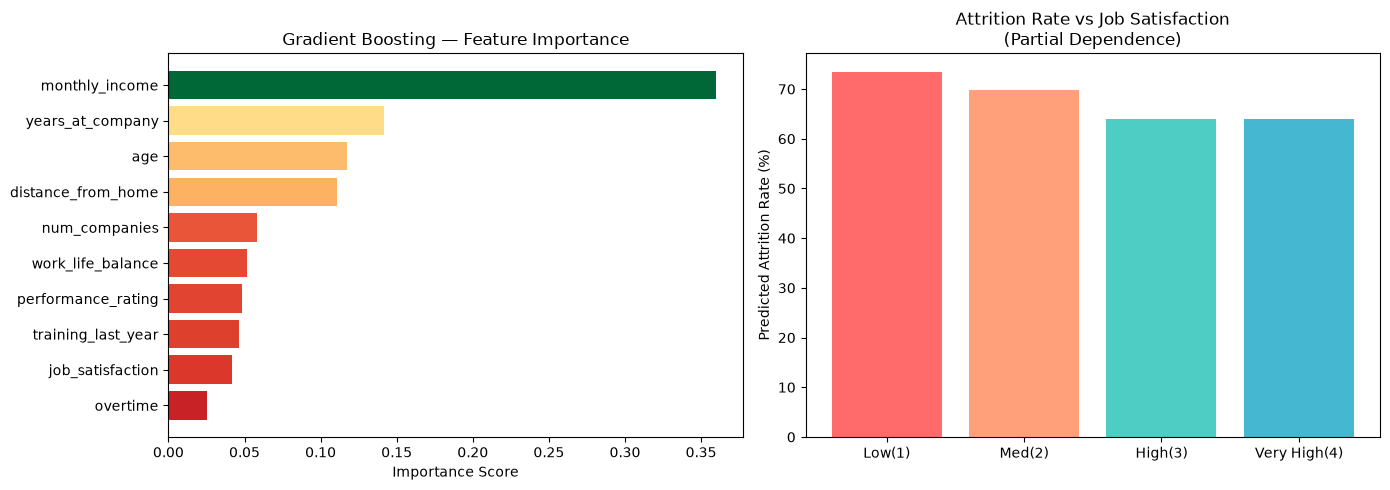

In [4]:
# Feature importance from Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, 
                                        max_depth=4, random_state=42)
gb_model.fit(X_tr_s, y_tr)

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance bar
colors = plt.cm.RdYlGn(imp_df['Importance'] / imp_df['Importance'].max())
axes[0].barh(imp_df['Feature'], imp_df['Importance'], color=colors)
axes[0].set_title("Gradient Boosting — Feature Importance")
axes[0].set_xlabel("Importance Score")

# Partial dependence style: job satisfaction vs attrition
js_range = np.arange(1, 5)
predictions = []
for js in js_range:
    X_temp = X_te.copy()
    X_temp['job_satisfaction'] = js
    X_temp_s = scaler.transform(X_temp)
    pred = gb_model.predict_proba(X_temp_s)[:,1].mean()
    predictions.append(pred)

axes[1].bar(['Low(1)','Med(2)','High(3)','Very High(4)'], 
             [p*100 for p in predictions], color=['#FF6B6B','#FFA07A','#4ECDC4','#45B7D1'])
axes[1].set_title("Attrition Rate vs Job Satisfaction\n(Partial Dependence)")
axes[1].set_ylabel("Predicted Attrition Rate (%)")

plt.tight_layout()
plt.savefig("/tmp/gbm_importance.png", dpi=100)
plt.show()

## 4. Learning Curves — Diagnosing Bias/Variance

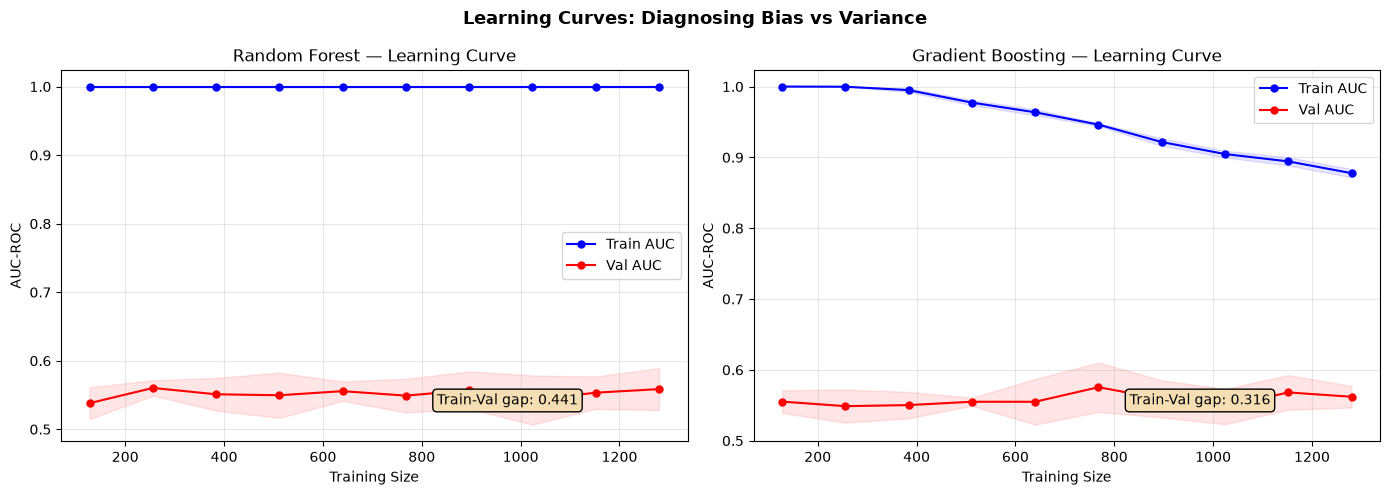

In [5]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ax, (name, model)) in enumerate(zip(axes, [
    ("Random Forest", RandomForestClassifier(n_estimators=50, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=42))
])):
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_tr_s, y_tr, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc', n_jobs=-1)

    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sizes, train_mean, 'b-o', ms=5, label='Train AUC')
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    ax.plot(train_sizes, val_mean, 'r-o', ms=5, label='Val AUC')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='red')
    ax.set_title(f"{name} — Learning Curve")
    ax.set_xlabel("Training Size"); ax.set_ylabel("AUC-ROC")
    ax.legend(); ax.grid(alpha=0.3)
    gap = (train_mean - val_mean)[-1]
    ax.text(0.6, 0.1, f'Train-Val gap: {gap:.3f}', transform=ax.transAxes,
                  fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle("Learning Curves: Diagnosing Bias vs Variance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/learning_curves.png", dpi=100)
plt.show()

## 5. Hyperparameter Guide for Gradient Boosting

| Parameter | Effect | Default | Tune Range |
|---|---|---|---|
| `n_estimators` | More trees = better | 100 | 100-1000 |
| `learning_rate` | Step size per tree | 0.1 | 0.01-0.3 |
| `max_depth` | Tree depth | 3 | 3-10 |
| `subsample` | Row sampling | 1.0 | 0.6-1.0 |
| `colsample_bytree` | Feature sampling | 1.0 | 0.6-1.0 |

**Rule:** Lower `learning_rate` + Higher `n_estimators` = better but slower.

=== Final Gradient Boosting Model ===
              precision    recall  f1-score   support

    Retained       0.44      0.25      0.32       130
    Attrited       0.70      0.85      0.77       270

    accuracy                           0.66       400
   macro avg       0.57      0.55      0.54       400
weighted avg       0.62      0.66      0.62       400

AUC-ROC: 0.5634


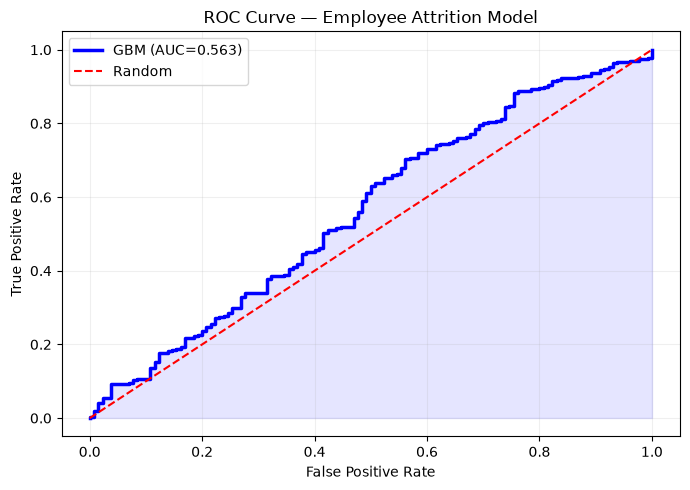

In [6]:
# Final evaluation: full report
y_pred_final = gb_model.predict(X_te_s)
y_prob_final = gb_model.predict_proba(X_te_s)[:,1]

print("=== Final Gradient Boosting Model ===")
print(classification_report(y_te, y_pred_final, target_names=['Retained','Attrited']))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_final):.4f}")

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_te, y_prob_final)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'GBM (AUC={roc_auc_score(y_te,y_prob_final):.3f})')
ax.plot([0,1],[0,1],'r--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='blue')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Employee Attrition Model")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("/tmp/gbm_roc.png", dpi=100)
plt.show()

## Summary

Gradient Boosting key insights:
- Build trees **sequentially**, each fixing errors of the previous
- **Learning rate** controls how much each tree contributes
- Use **early stopping** to avoid overfitting (stop when val loss plateaus)
- XGBoost/LightGBM are optimized versions — use them in practice

**Next notebook →** `12_Clustering_KMeans.ipynb`